# Super Tic-Tac-Toe Benchmark (RLlib)

This notebook keeps the overall structure of the original benchmark, but:

- Uses **RLlib only**: `PPO`, `IMPALA`, `APPO`.
- Removes all Chinese text.
- Training schedule:
  - First **70%** of training: **deterministic placement** (`stochastic_moves=False`).
  - Last **30%** of training: **stochastic placement** (`stochastic_moves=True`, `accept_prob=0.5`).
  - Additionally, the **first 5 actions of every episode** are forced to be **random valid moves** (to avoid always training on exactly the same opening trajectory).
- Evaluation:
  - Evaluate under **deterministic** and **stochastic** environments separately.
- Plotting:
  - A **red dashed vertical line** marks the switch from deterministic to stochastic training in the **episode length** plot.


In [1]:
import sys
import subprocess
from importlib import metadata as md

def _pip(*args):
    cmd = [sys.executable, "-m", "pip", *args]
    print(">>", " ".join(cmd))
    subprocess.check_call(cmd)

def _ver(name: str):
    try:
        return md.version(name)
    except md.PackageNotFoundError:
        return None

np_ver = _ver("numpy")
print("NumPy version (metadata):", np_ver)
if np_ver is None or int(np_ver.split(".")[0]) >= 2:
    _pip("install", "-U", "--force-reinstall", "--no-cache-dir", "numpy<2")
    print("NumPy has been downgraded. Please restart the kernel and continue from the next cell.")
    raise SystemExit


NumPy version (metadata): 1.26.4


In [2]:
import os
os.environ.setdefault("TORCHDYNAMO_DISABLE", "1")
os.environ.setdefault("RAY_DISABLE_DASHBOARD", "1")
os.environ.setdefault("RAY_USAGE_STATS_ENABLED", "0")
os.environ.setdefault("RAY_DEDUP_LOGS", "0")

import time
import random
from typing import Dict, Optional, Tuple

import numpy as np
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn

from tqdm.auto import tqdm
import pandas as pd

import sys
import importlib.abc
import importlib.machinery

SEED = 42

ITERS = 1000
EVAL_EVERY = 50
EVAL_EPISODES = 250
FINAL_EVAL_EPISODES = 500

TRAIN_DET_FRAC = 0.5
OPENING_RANDOM_MOVES_TRAIN = 5
TRAIN_STOCH_ACCEPT_PROB = 0.5

EVAL_DET_ACCEPT_PROB = 1.0
EVAL_STOCH_ACCEPT_PROB = 0.5
OPENING_RANDOM_MOVES_EVAL = 25

ALGOS_TO_RUN = ["PPO"]


def set_global_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(int(seed))
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_global_seeds(SEED)

has_cuda = bool(getattr(torch, "cuda", None) and torch.cuda.is_available() and (torch.version.cuda is not None))
NUM_GPUS = 1 if has_cuda else 0
device = torch.device("cuda:0" if has_cuda else "cpu")
print("Using device:", device, "| num_gpus:", NUM_GPUS, "| torch.cuda:", getattr(torch.version, "cuda", None))


FORCE_TF_IMPORT_ERROR_FOR_RLLIB = True


class _TensorflowImportBlocker(importlib.abc.MetaPathFinder, importlib.abc.Loader):
    def find_spec(self, fullname, path=None, target=None):
        if fullname == "tensorflow" or fullname.startswith("tensorflow."):
            return importlib.machinery.ModuleSpec(fullname, self)
        return None

    def create_module(self, spec):
        return None

    def exec_module(self, module):
        raise ModuleNotFoundError("tensorflow import blocked for RLlib (torch-only)")


def force_tensorflow_import_error():
    for k in list(sys.modules.keys()):
        if k == "tensorflow" or k.startswith("tensorflow."):
            sys.modules.pop(k, None)
    if not any(isinstance(f, _TensorflowImportBlocker) for f in sys.meta_path):
        sys.meta_path.insert(0, _TensorflowImportBlocker())


if FORCE_TF_IMPORT_ERROR_FOR_RLLIB:
    force_tensorflow_import_error()


import ray


def init_ray():
    try:
        if ray.is_initialized():
            ray.shutdown()
    except Exception:
        pass
    try:
        ray.init(ignore_reinit_error=True, include_dashboard=False, num_gpus=int(NUM_GPUS), num_cpus=1, log_to_driver=True)
    except Exception:
        ray.init(ignore_reinit_error=True, include_dashboard=False, local_mode=True, num_gpus=int(NUM_GPUS), num_cpus=1, log_to_driver=True)


init_ray()
print("Ray initialized:", ray.is_initialized())


Using device: cuda:0 | num_gpus: 1 | torch.cuda: 12.1


2026-05-09 07:26:28,232	INFO worker.py:2012 -- Started a local Ray instance.


Ray initialized: True


d:\anconda\Lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [3]:
from ray.rllib.env.multi_agent_env import MultiAgentEnv


class SuperTicTacToeMultiAgentEnv(MultiAgentEnv):
    def __init__(self, config: Optional[dict] = None):
        super().__init__()
        config = config or {}
        seed = int(config.get("seed", 0))

        self.stochastic_moves = bool(config.get("stochastic_moves", True))
        self.accept_prob = float(config.get("accept_prob", 0.5))
        self.opening_random_moves = int(config.get("opening_random_moves", 0))

        stoch_by_agent = config.get("stochastic_moves_by_agent")
        if stoch_by_agent is None:
            stoch_by_agent = {
                "player1": bool(config.get("stochastic_moves_player1", self.stochastic_moves)),
                "player2": bool(config.get("stochastic_moves_player2", self.stochastic_moves)),
            }
        self.stochastic_moves_by_agent = {
            aid: bool(stoch_by_agent.get(aid, self.stochastic_moves)) for aid in ["player1", "player2"]
        }

        accept_by_agent = config.get("accept_prob_by_agent")
        if accept_by_agent is None:
            accept_by_agent = {
                "player1": float(config.get("accept_prob_player1", self.accept_prob)),
                "player2": float(config.get("accept_prob_player2", self.accept_prob)),
            }
        self.accept_prob_by_agent = {
            aid: float(accept_by_agent.get(aid, self.accept_prob)) for aid in ["player1", "player2"]
        }

        self.reward_3 = float(config.get("reward_3", 0.5))
        self.reward_4 = float(config.get("reward_4", 0.5))
        self.shaping_scale = float(config.get("shaping_scale", 0.05))
        self.step_penalty = float(config.get("step_penalty", 0.001))
        self.shaping_cap = float(config.get("shaping_cap", 0.3))
        self._shaping_prev = {"player1": {"c3": 0, "c4": 0}, "player2": {"c3": 0, "c4": 0}}
        self._shaping_total = {"player1": 0.0, "player2": 0.0}

        self.square_size = 4
        self.square_positions = {
            0: (0, 0),
            1: (1, 0),
            2: (1, 1),
            3: (2, 0),
            4: (2, 1),
            5: (2, 2),
        }
        self.block_to_square = {v: k for k, v in self.square_positions.items()}
        self.num_squares = len(self.square_positions)

        self.total_cells = self.num_squares * self.square_size * self.square_size
        self.global_blocks = 3
        self.global_size = self.global_blocks * self.square_size

        self.valid_mask = np.zeros((self.global_size, self.global_size), dtype=bool)
        for _, (br, bc) in self.square_positions.items():
            r0 = br * self.square_size
            c0 = bc * self.square_size
            self.valid_mask[r0 : r0 + self.square_size, c0 : c0 + self.square_size] = True

        self.board = np.zeros((self.num_squares, self.square_size, self.square_size), dtype=np.int8)

        self.action_space = spaces.Discrete(self.total_cells)
        self.observation_space = spaces.Dict(
            {
                "obs": spaces.Box(low=-1.0, high=1.0, shape=(self.total_cells,), dtype=np.float32),
                "action_mask": spaces.Box(low=0, high=1, shape=(self.total_cells,), dtype=np.int8),
            }
        )

        self._neighbor_dirs = [
            (-1, -1),
            (-1, 0),
            (-1, 1),
            (0, -1),
            (0, 1),
            (1, -1),
            (1, 0),
            (1, 1),
        ]

        self._rng = np.random.default_rng(int(seed))
        self._agents = ["player1", "player2"]
        self._player_value = {"player1": 1, "player2": -1}
        self._current_agent = "player1"
        self._turn_count = 0

        self.possible_agents = list(self._agents)
        self.agents = list(self._agents)
        self.observation_spaces = {aid: self.observation_space for aid in self._agents}
        self.action_spaces = {aid: self.action_space for aid in self._agents}

    def set_mode(
        self,
        stochastic_moves: Optional[bool] = None,
        accept_prob: Optional[float] = None,
        stochastic_moves_by_agent: Optional[dict] = None,
        accept_prob_by_agent: Optional[dict] = None,
    ):
        if stochastic_moves is not None:
            self.stochastic_moves = bool(stochastic_moves)
            self.stochastic_moves_by_agent = {aid: bool(self.stochastic_moves) for aid in self._agents}
        if accept_prob is not None:
            self.accept_prob = float(accept_prob)
            self.accept_prob_by_agent = {aid: float(self.accept_prob) for aid in self._agents}
        if stochastic_moves_by_agent is not None:
            for aid in self._agents:
                if aid in stochastic_moves_by_agent:
                    self.stochastic_moves_by_agent[aid] = bool(stochastic_moves_by_agent[aid])
        if accept_prob_by_agent is not None:
            for aid in self._agents:
                if aid in accept_prob_by_agent:
                    self.accept_prob_by_agent[aid] = float(accept_prob_by_agent[aid])

    def _action_to_coord(self, action: int) -> Tuple[int, int, int]:
        square = action // (self.square_size * self.square_size)
        remainder = action % (self.square_size * self.square_size)
        row = remainder // self.square_size
        col = remainder % self.square_size
        return int(square), int(row), int(col)

    def _coord_to_action(self, square: int, row: int, col: int) -> int:
        return int(square * self.square_size * self.square_size + row * self.square_size + col)

    def _square_cell_to_global(self, square: int, row: int, col: int):
        br, bc = self.square_positions[int(square)]
        return int(br * self.square_size + row), int(bc * self.square_size + col)

    def _global_to_square_cell(self, g_row: int, g_col: int) -> Optional[Tuple[int, int, int]]:
        if not (0 <= g_row < self.global_size and 0 <= g_col < self.global_size):
            return None
        if not self.valid_mask[g_row, g_col]:
            return None
        br = g_row // self.square_size
        bc = g_col // self.square_size
        square = self.block_to_square.get((int(br), int(bc)))
        if square is None:
            return None
        row = g_row % self.square_size
        col = g_col % self.square_size
        return int(square), int(row), int(col)

    def _board_global(self) -> np.ndarray:
        g = np.zeros((self.global_size, self.global_size), dtype=np.int8)
        for square, (br, bc) in self.square_positions.items():
            r0 = br * self.square_size
            c0 = bc * self.square_size
            g[r0 : r0 + self.square_size, c0 : c0 + self.square_size] = self.board[square]
        return g

    def _count_k(self, player: int, k: int) -> int:
        g = self._board_global()
        mask = self.valid_mask
        n = self.global_size
        count = 0

        for r in range(n):
            for c in range(n - k + 1):
                if mask[r, c : c + k].all() and np.all(g[r, c : c + k] == player):
                    count += 1

        for r in range(n - k + 1):
            for c in range(n):
                if mask[r : r + k, c].all() and np.all(g[r : r + k, c] == player):
                    block_rows = {int((r + i) // self.square_size) for i in range(k)}
                    if len(block_rows) >= 2:
                        count += 1

        for r in range(n - k + 1):
            for c in range(n - k + 1):
                coords = [(r + i, c + i) for i in range(k)]
                if all(mask[rr, cc] for rr, cc in coords) and all(g[rr, cc] == player for rr, cc in coords):
                    count += 1

        for r in range(n - k + 1):
            for c in range(k - 1, n):
                coords = [(r + i, c - i) for i in range(k)]
                if all(mask[rr, cc] for rr, cc in coords) and all(g[rr, cc] == player for rr, cc in coords):
                    count += 1

        return int(count)

    def _shaping_reward(self, agent_id: str, player: int) -> float:
        cur3 = self._count_k(player=player, k=3)
        cur4 = self._count_k(player=player, k=4)
        prev = self._shaping_prev.get(agent_id, {"c3": 0, "c4": 0})
        delta3 = max(0, int(cur3) - int(prev.get("c3", 0)))
        delta4 = max(0, int(cur4) - int(prev.get("c4", 0)))
        self._shaping_prev[agent_id] = {"c3": int(cur3), "c4": int(cur4)}
        base = float(self.reward_3) * float(delta3) + float(self.reward_4) * float(delta4)
        return float(self.shaping_scale) * float(base)

    def _check_win(self, player: int) -> bool:
        g = self._board_global()
        mask = self.valid_mask
        n = self.global_size

        for r in range(n):
            for c in range(n - 3):
                if mask[r, c : c + 4].all() and np.all(g[r, c : c + 4] == player):
                    return True

        for r in range(n - 3):
            for c in range(n):
                if mask[r : r + 4, c].all() and np.all(g[r : r + 4, c] == player):
                    block_rows = {int((r + i) // self.square_size) for i in range(4)}
                    if len(block_rows) >= 2:
                        return True

        for r in range(n - 4):
            for c in range(n - 4):
                coords = [(r + i, c + i) for i in range(5)]
                if all(mask[rr, cc] for rr, cc in coords) and all(g[rr, cc] == player for rr, cc in coords):
                    return True

        for r in range(n - 4):
            for c in range(4, n):
                coords = [(r + i, c - i) for i in range(5)]
                if all(mask[rr, cc] for rr, cc in coords) and all(g[rr, cc] == player for rr, cc in coords):
                    return True

        return False

    def _is_board_full(self) -> bool:
        return bool(np.all(self.board != 0))

    def _get_obs(self) -> dict:
        flat = self.board.reshape(-1)
        return {"obs": flat.astype(np.float32), "action_mask": (flat == 0).astype(np.int8)}

    def _apply_move(self, action: int, player: int, stochastic_moves: bool, accept_prob: float) -> Optional[int]:
        square, row, col = self._action_to_coord(int(action))
        if self.board[square, row, col] != 0:
            return None

        if not bool(stochastic_moves):
            self.board[square, row, col] = player
            return int(action)

        if self._rng.random() < float(accept_prob):
            self.board[square, row, col] = player
            return int(action)

        g_row, g_col = self._square_cell_to_global(square, row, col)
        dr, dc = self._neighbor_dirs[int(self._rng.integers(0, 8))]
        target = self._global_to_square_cell(g_row + int(dr), g_col + int(dc))
        if target is None:
            return None
        t_square, t_row, t_col = target
        if self.board[t_square, t_row, t_col] != 0:
            return None
        self.board[t_square, t_row, t_col] = player
        return self._coord_to_action(t_square, t_row, t_col)

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(int(seed))
        self.board.fill(0)
        self._current_agent = "player1"
        self._turn_count = 0
        self._shaping_prev = {"player1": {"c3": 0, "c4": 0}, "player2": {"c3": 0, "c4": 0}}
        self._shaping_total = {"player1": 0.0, "player2": 0.0}
        self.agents = list(self._agents)
        obs = {self._current_agent: self._get_obs()}
        infos = {self._current_agent: {}}
        return obs, infos

    def step(self, action_dict: Dict[str, int]):
        agent_id = self._current_agent
        player = int(self._player_value[agent_id])

        stochastic_moves = bool(self.stochastic_moves_by_agent.get(agent_id, self.stochastic_moves))
        accept_prob = float(self.accept_prob_by_agent.get(agent_id, self.accept_prob))

        if self._turn_count < int(self.opening_random_moves):
            obs_dict = self._get_obs()
            mask = obs_dict.get("action_mask")
            valid = np.flatnonzero(np.asarray(mask) > 0)
            action = int(self._rng.choice(valid)) if len(valid) > 0 else int(self.action_space.sample())
        else:
            action = int(action_dict[agent_id])

        _ = self._apply_move(action, player=player, stochastic_moves=stochastic_moves, accept_prob=accept_prob)
        self._turn_count += 1
        raw_shaping = float(self._shaping_reward(agent_id=agent_id, player=player))
        cap_remaining = float(self.shaping_cap) - float(self._shaping_total.get(agent_id, 0.0))
        capped_shaping = float(min(raw_shaping, max(0.0, cap_remaining)))
        self._shaping_total[agent_id] = float(self._shaping_total.get(agent_id, 0.0) + capped_shaping)
        shaping_r = float(capped_shaping - float(self.step_penalty))

        if self._check_win(player):
            self.agents = []
            rewards = {"player1": 1.0, "player2": -1.0} if player == 1 else {"player1": -1.0, "player2": 1.0}
            rewards[agent_id] = float(rewards.get(agent_id, 0.0) + shaping_r)
            terminateds = {"__all__": True, "player1": True, "player2": True}
            truncateds = {"__all__": False, "player1": False, "player2": False}
            return {}, rewards, terminateds, truncateds, {}

        if self._is_board_full():
            self.agents = []
            rewards = {"player1": 0.0, "player2": 0.0}
            rewards[agent_id] = float(rewards.get(agent_id, 0.0) + shaping_r)
            terminateds = {"__all__": True, "player1": True, "player2": True}
            truncateds = {"__all__": False, "player1": False, "player2": False}
            return {}, rewards, terminateds, truncateds, {}

        self._current_agent = "player2" if agent_id == "player1" else "player1"
        obs = {self._current_agent: self._get_obs()}
        terminateds = {"__all__": False, "player1": False, "player2": False}
        truncateds = {"__all__": False, "player1": False, "player2": False}
        infos = {self._current_agent: {}}
        return obs, {agent_id: float(shaping_r)}, terminateds, truncateds, infos


In [ ]:
from ray.tune.registry import register_env
from ray.rllib.models import ModelCatalog
from ray.rllib.models.torch.fcnet import FullyConnectedNetwork
from ray.rllib.models.torch.torch_modelv2 import TorchModelV2


def env_creator(env_config):
    return SuperTicTacToeMultiAgentEnv(env_config)


register_env("super_ttt_ma_bench", env_creator)

_tmp_env = SuperTicTacToeMultiAgentEnv({"seed": SEED, "stochastic_moves": True, "accept_prob": 0.5, "opening_random_moves": 0})
obs_space = _tmp_env.observation_space
act_space = _tmp_env.action_space


class ActionMaskModel(TorchModelV2, nn.Module):
    def __init__(self, obs_space, action_space, num_outputs, model_config, name):
        TorchModelV2.__init__(self, obs_space, action_space, num_outputs, model_config, name)
        nn.Module.__init__(self)
        obs_len = int(getattr(action_space, "n", 0))
        obs_only_space = spaces.Box(low=-1.0, high=1.0, shape=(obs_len,), dtype=np.float32)
        self._internal = FullyConnectedNetwork(obs_only_space, action_space, num_outputs, model_config, name + "_fc")

    def forward(self, input_dict, state, seq_lens):
        raw = input_dict["obs"]
        obs = raw["obs"] if isinstance(raw, dict) else raw
        mask = raw["action_mask"] if isinstance(raw, dict) else None
        logits, state = self._internal({"obs": obs}, state, seq_lens)
        if mask is None:
            return logits, state
        inf_mask = torch.where(
            mask > 0,
            torch.zeros_like(mask, dtype=logits.dtype),
            torch.full_like(mask, -1e9, dtype=logits.dtype),
        )
        return logits + inf_mask, state

    def value_function(self):
        return self._internal.value_function()


ModelCatalog.register_custom_model("action_mask_model_bench", ActionMaskModel)

policies = {
    "player1": (None, obs_space, act_space, {"model": {"custom_model": "action_mask_model_bench"}}),
    "player2": (None, obs_space, act_space, {"model": {"custom_model": "action_mask_model_bench"}}),
}


: 

In [ ]:
import re
import matplotlib.pyplot as plt


def evaluate_rllib(
    algo,
    n_episodes=80,
    seed=10000,
    stochastic_moves=True,
    accept_prob=0.5,
    opening_random_moves=0,
    stochastic_moves_by_agent=None,
    accept_prob_by_agent=None,
):
    env_config = {
        "seed": int(seed),
        "stochastic_moves": bool(stochastic_moves),
        "accept_prob": float(accept_prob),
        "opening_random_moves": int(opening_random_moves),
    }
    if stochastic_moves_by_agent is not None:
        env_config["stochastic_moves_by_agent"] = dict(stochastic_moves_by_agent)
    if accept_prob_by_agent is not None:
        env_config["accept_prob_by_agent"] = dict(accept_prob_by_agent)
    env = SuperTicTacToeMultiAgentEnv(env_config)
    p1_wins = p2_wins = draws = 0
    for ep in range(int(n_episodes)):
        obs, _ = env.reset(seed=int(seed) + ep)
        terminated = {"__all__": False}
        truncated = {"__all__": False}
        ep_ret = {"player1": 0.0, "player2": 0.0}
        while (not terminated["__all__"]) and (not truncated["__all__"]):
            if not obs:
                break
            agent_id = next(iter(obs.keys()))
            a = algo.compute_single_action(obs[agent_id], policy_id=agent_id, explore=False)
            if isinstance(a, tuple):
                a = a[0]
            obs, rewards, terminated, truncated, _ = env.step({agent_id: int(a)})
            for k, v in rewards.items():
                ep_ret[k] = float(ep_ret.get(k, 0.0) + float(v))
        if ep_ret.get("player1", 0.0) > 0:
            p1_wins += 1
        elif ep_ret.get("player1", 0.0) < 0:
            p2_wins += 1
        else:
            draws += 1
    return {"p1_win": p1_wins / n_episodes, "p2_win": p2_wins / n_episodes, "draw": draws / n_episodes}


def apply_common_config(config):
    if hasattr(config, "api_stack"):
        try:
            config = config.api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)
        except TypeError:
            try:
                config = config.api_stack(enable_rl_module_and_learner=False)
            except Exception:
                pass

    if hasattr(config, "env_runners"):
        try:
            config = config.env_runners(num_env_runners=0)
        except TypeError:
            config = config.env_runners(num_rollout_workers=0)
    else:
        config = config.rollouts(num_rollout_workers=0)

    config = config.resources(num_gpus=int(NUM_GPUS))
    config = config.multi_agent(
        policies=policies,
        policy_mapping_fn=lambda agent_id, *args, **kwargs: agent_id,
        policies_to_train=["player1", "player2"],
    )
    return config


def robust_training_config(config, kwargs):
    local_kwargs = dict(kwargs)
    while True:
        try:
            return config.training(**local_kwargs)
        except TypeError as e:
            m = re.search(r"unexpected keyword argument '([^']+)'", str(e))
            if not m:
                raise
            local_kwargs.pop(m.group(1), None)
            if not local_kwargs:
                raise


def build_rllib_configs(seed=0):
    algos = {}
    from ray.rllib.algorithms.ppo import PPOConfig
    ppo = PPOConfig().environment(
        env="super_ttt_ma_bench",
        env_config={
            "seed": int(seed),
            "stochastic_moves": False,
            "accept_prob": 1.0,
            "opening_random_moves": int(OPENING_RANDOM_MOVES_TRAIN),
        },
    ).framework("torch")
    if hasattr(ppo, "debugging"):
        try:
            ppo = ppo.debugging(seed=int(seed))
        except TypeError:
            pass
    ppo = apply_common_config(ppo)
    ppo = robust_training_config(
        ppo,
        {"gamma": 0.99, "lr": 3e-4, "train_batch_size": 2048, "sgd_minibatch_size": 64, "num_sgd_iter": 10, "minibatch_size": 64, "num_epochs": 10},
    )
    algos["PPO"] = ppo

    from ray.rllib.algorithms.impala import ImpalaConfig
    impala = ImpalaConfig().environment(
        env="super_ttt_ma_bench",
        env_config={
            "seed": int(seed),
            "stochastic_moves": False,
            "accept_prob": 1.0,
            "opening_random_moves": int(OPENING_RANDOM_MOVES_TRAIN),
        },
    ).framework("torch")
    if hasattr(impala, "debugging"):
        try:
            impala = impala.debugging(seed=int(seed))
        except TypeError:
            pass
    impala = apply_common_config(impala)
    impala = robust_training_config(impala, {"gamma": 0.99, "lr": 3e-4, "train_batch_size": 1024, "rollout_fragment_length": 50})
    algos["IMPALA"] = impala

    from ray.rllib.algorithms.appo import APPOConfig
    appo = APPOConfig().environment(
        env="super_ttt_ma_bench",
        env_config={
            "seed": int(seed),
            "stochastic_moves": False,
            "accept_prob": 1.0,
            "opening_random_moves": int(OPENING_RANDOM_MOVES_TRAIN),
        },
    ).framework("torch")
    if hasattr(appo, "debugging"):
        try:
            appo = appo.debugging(seed=int(seed))
        except TypeError:
            pass
    appo = apply_common_config(appo)
    appo = robust_training_config(appo, {"gamma": 0.99, "lr": 2e-4, "train_batch_size": 1024, "rollout_fragment_length": 50})
    algos["APPO"] = appo

    return algos


def _set_env_mode(env, stochastic_moves=None, accept_prob=None, stochastic_moves_by_agent=None, accept_prob_by_agent=None):
    try:
        env.set_mode(
            stochastic_moves=stochastic_moves,
            accept_prob=accept_prob,
            stochastic_moves_by_agent=stochastic_moves_by_agent,
            accept_prob_by_agent=accept_prob_by_agent,
        )
        return
    except Exception:
        pass
    try:
        if stochastic_moves is not None:
            env.stochastic_moves = bool(stochastic_moves)
        if accept_prob is not None:
            env.accept_prob = float(accept_prob)
        if stochastic_moves_by_agent is not None:
            env.stochastic_moves_by_agent = {k: bool(v) for k, v in dict(stochastic_moves_by_agent).items()}
        if accept_prob_by_agent is not None:
            env.accept_prob_by_agent = {k: float(v) for k, v in dict(accept_prob_by_agent).items()}
    except Exception:
        pass


def _switch_algo_envs(algo, stochastic_moves=None, accept_prob=None, stochastic_moves_by_agent=None, accept_prob_by_agent=None):
    try:
        algo.workers.foreach_worker(
            lambda w: w.foreach_env(
                lambda e: _set_env_mode(e, stochastic_moves, accept_prob, stochastic_moves_by_agent, accept_prob_by_agent)
            )
        )
        return
    except Exception:
        pass
    try:
        algo.workers.local_worker().foreach_env(
            lambda e: _set_env_mode(e, stochastic_moves, accept_prob, stochastic_moves_by_agent, accept_prob_by_agent)
        )
    except Exception:
        pass


def train_rllib_variant(name, cfg, iters=200, eval_every=20, n_eval_episodes=80, final_eval_episodes=100):
    algo = None
    train_len_mean = []
    eval_rows = []
    try:
        tqdm.write(f"{name}: building ...")
        t_build0 = time.time()
        algo = cfg.build_algo() if hasattr(cfg, "build_algo") else cfg.build()
        t_build = time.time() - t_build0
        tqdm.write(f"{name}: built in {t_build:.1f}s")

        switch_it = int(max(1, round(TRAIN_DET_FRAC * float(iters))))
        switched = False

        for it in tqdm(range(1, int(iters) + 1), desc=f"{name} train"):
            if (not switched) and it == switch_it:
                _switch_algo_envs(algo, stochastic_moves=True, accept_prob=float(TRAIN_STOCH_ACCEPT_PROB))
                switched = True

            t0 = time.time()
            res = algo.train()
            t_train = time.time() - t0
            mean_len = res.get("env_runners", {}).get("episode_len_mean", res.get("episode_len_mean", 0.0))
            train_len_mean.append(float(mean_len))

            do_eval = (it % int(eval_every) == 0) or (it == int(iters))
            if not do_eval:
                continue

            n_eps = int(final_eval_episodes if it == int(iters) else n_eval_episodes)
            t1 = time.time()
            det = evaluate_rllib(
                algo,
                n_episodes=n_eps,
                seed=10000 + it,
                stochastic_moves=False,
                accept_prob=float(EVAL_DET_ACCEPT_PROB),
                opening_random_moves=int(OPENING_RANDOM_MOVES_EVAL),
            )
            stoch = evaluate_rllib(
                algo,
                n_episodes=n_eps,
                seed=20000 + it,
                stochastic_moves=True,
                accept_prob=float(EVAL_STOCH_ACCEPT_PROB),
                opening_random_moves=int(OPENING_RANDOM_MOVES_EVAL),
            )
            t_eval = time.time() - t1

            row = {
                "algo": name,
                "iter": int(it),
                "train_s": float(t_train),
                "eval_s": float(t_eval),
                "train_len_mean": float(mean_len),
                "det_p1": float(det["p1_win"]),
                "det_p2": float(det["p2_win"]),
                "det_draw": float(det["draw"]),
                "stoch_p1": float(stoch["p1_win"]),
                "stoch_p2": float(stoch["p2_win"]),
                "stoch_draw": float(stoch["draw"]),
            }
            eval_rows.append(row)
            tqdm.write(
                f"{name} it={it:04d} len={mean_len:.1f} det_p1={row['det_p1']:.3f} stoch_p1={row['stoch_p1']:.3f}"
            )
    finally:
        if algo is not None:
            try:
                algo.stop()
            except Exception:
                pass
    return {"train_len_mean": train_len_mean, "eval_rows": eval_rows}


rllib_configs = build_rllib_configs(seed=SEED)

selected = [a for a in ALGOS_TO_RUN if a in rllib_configs]
benchmark = {}

for name in selected:
    benchmark[name] = train_rllib_variant(
        name,
        rllib_configs[name],
        iters=ITERS,
        eval_every=EVAL_EVERY,
        n_eval_episodes=EVAL_EPISODES,
        final_eval_episodes=FINAL_EVAL_EPISODES,
    )

rows = []
for algo_name, pack in benchmark.items():
    rows.extend(pack["eval_rows"])

df = pd.DataFrame(rows).sort_values(["algo", "iter"]).reset_index(drop=True)
display(df)

df_final = df.sort_values(["algo", "iter"]).groupby("algo", as_index=False).tail(1).reset_index(drop=True)
display(df_final)

switch_x = int(max(1, round(TRAIN_DET_FRAC * float(ITERS))))

fig, ax = plt.subplots(1, 3, figsize=(21, 5))

for algo_name, pack in benchmark.items():
    ax[0].plot(range(1, len(pack["train_len_mean"]) + 1), pack["train_len_mean"], label=algo_name)
ax[0].axvline(x=switch_x, color="red", linestyle="--", linewidth=2, label="switch det→stoch")
ax[0].set_title("Train Episode Length Mean")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Steps")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for algo_name, g in df.groupby("algo"):
    line_stoch, = ax[1].plot(g["iter"], g["stoch_p1"], linestyle="-", label=f"{algo_name} stoch")
    ax[1].plot(g["iter"], g["det_p1"], linestyle="--", color=line_stoch.get_color(), label=f"{algo_name} det")
ax[1].set_title("P1 Win Rate (det vs stoch)")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Rate")
ax[1].set_ylim(0, 1)
ax[1].grid(True, alpha=0.3)
ax[1].legend(ncol=2)

for algo_name, g in df.groupby("algo"):
    line_stoch, = ax[2].plot(g["iter"], g["stoch_p2"], linestyle="-", label=f"{algo_name} stoch")
    ax[2].plot(g["iter"], g["det_p2"], linestyle="--", color=line_stoch.get_color(), label=f"{algo_name} det")
ax[2].set_title("P2 Win Rate (det vs stoch)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Rate")
ax[2].set_ylim(0, 1)
ax[2].grid(True, alpha=0.3)
ax[2].legend(ncol=2)

plt.tight_layout()
plt.show()


2026-05-09 07:26:39,888	WARNING algorithm_config.py:2516 -- DeprecationWarning: `config.training(num_sgd_iter=..)` has been deprecated. Use `config.training(num_epochs=..)` instead. This will raise an error in the future!


PPO: building ...


2026-05-09 07:26:49,871	WARNING util.py:62 -- Install gputil for GPU system monitoring.


PPO: built in 10.1s


PPO train:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-05-09 07:27:26,729	WARNING sgd.py:55 -- DeprecationWarning: `_get_slice_indices` has been deprecated. This will raise an error in the future!
2026-05-09 07:59:11,577	WARNING 3016936350.py:36 -- DeprecationWarning: `compute_single_action` has been deprecated. `Algorithm.compute_single_action` should no longer be used. Get the RLModule instance through `Algorithm.get_module([module ID])`, then compute actions through `RLModule.forward_inference({'obs': [obs batch]})`. This will raise an error in the future!


PPO it=0050 len=41.5 det_p1=0.400 stoch_p1=0.432
PPO it=0100 len=27.7 det_p1=0.388 stoch_p1=0.372
PPO it=0150 len=21.1 det_p1=0.284 stoch_p1=0.296
PPO it=0200 len=15.5 det_p1=0.316 stoch_p1=0.384
PPO it=0250 len=13.1 det_p1=0.272 stoch_p1=0.408
PPO it=0300 len=12.3 det_p1=0.316 stoch_p1=0.424
PPO it=0350 len=12.2 det_p1=0.336 stoch_p1=0.408
PPO it=0400 len=11.5 det_p1=0.316 stoch_p1=0.396
PPO it=0450 len=11.9 det_p1=0.320 stoch_p1=0.352
PPO it=0500 len=12.6 det_p1=0.364 stoch_p1=0.344
PPO it=0550 len=12.7 det_p1=0.332 stoch_p1=0.364
PPO it=0600 len=12.7 det_p1=0.316 stoch_p1=0.408
PPO it=0650 len=13.1 det_p1=0.340 stoch_p1=0.360
PPO it=0700 len=13.7 det_p1=0.356 stoch_p1=0.440
PPO it=0750 len=13.6 det_p1=0.332 stoch_p1=0.420
PPO it=0800 len=13.4 det_p1=0.316 stoch_p1=0.432
PPO it=0850 len=14.3 det_p1=0.324 stoch_p1=0.456
PPO it=0900 len=13.0 det_p1=0.348 stoch_p1=0.396
PPO it=0950 len=13.0 det_p1=0.352 stoch_p1=0.412
PPO it=1000 len=12.9 det_p1=0.332 stoch_p1=0.376


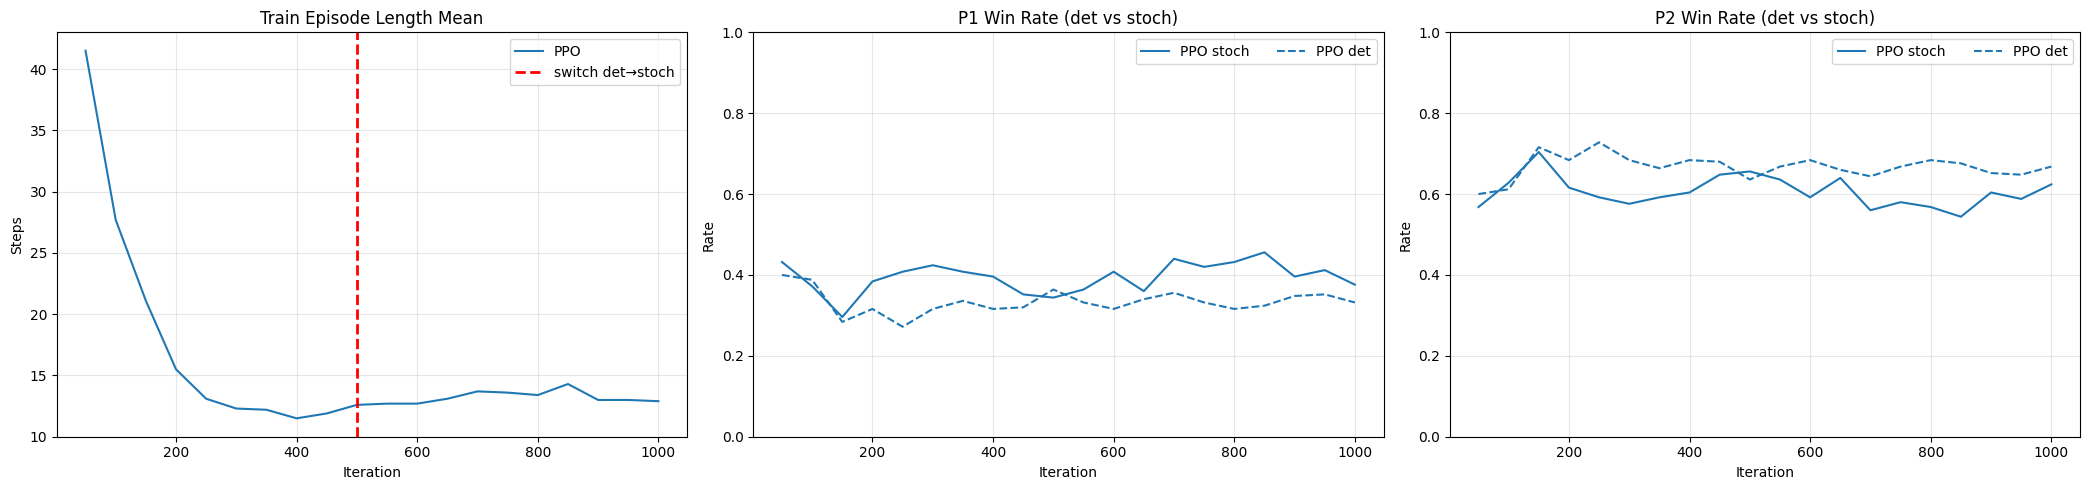